# GDL - Midterm n.3

In the third midterm assignment, you are required to implement an **Adversarial Autoencoder (AAE)** ([Makhzani et al., 2015](https://arxiv.org/abs/1511.05644)).

An AAE is a generative model that regularises its latent space not through a closed-form KL divergence, but *adversarially*: a discriminator $D_\psi$ is trained to distinguish latent codes produced by the encoder $z \sim q_\phi(z|x)$ from samples drawn from the chosen prior $p(z)$; the encoder is also simultaneously trained as a generator that tries to fool $D_\psi$.

⚠️ Read **carefully** the project description and in particular the **evaluation subsection**!

## Project Description

### Model
The three networks are:
- **Encoder** $q_\phi(z\mid x)$: maps an image $x$ to a latent code $z \in \mathbb{R}^d$.
- **Decoder** $p_\theta(\hat x\mid z)$: reconstructs $x$ from $z$.
- **Discriminator** $D_\psi(z) \in [0,1]$: estimates the probability that $z$ comes from the prior $p(z) = \mathcal{N}(\mathbf{0}, I)$.

### Training Objectives

Training alternates between two phases per mini-batch:

*Phase 1 — Reconstruction.* Update encoder $\phi$ and decoder $\theta$ to minimise the reconstruction loss:
$$
\mathcal{L}_{\text{recon}} = -\mathbb{E}_{p(x)}\bigl[\log p_\theta(x \mid q_\phi(x))\bigr]
\approx \mathrm{BCE}(\hat x, x).
$$

*Phase 2 — Adversarial regularisation.* Two gradient steps:

1. **Discriminator step** — update $\psi$ to distinguish prior samples (labelled *real*) from encoder outputs (labelled *fake*):
$$
\mathcal{L}_{D} = -\mathbb{E}_{z \sim p(z)}[\log D_\psi(z)] - \mathbb{E}_{x \sim p(x)}[\log(1 - D_\psi(q_\phi(x)))].
$$

2. **Generator step** — update $\phi$ only, to fool the discriminator:
$$
\mathcal{L}_{G} = -\mathbb{E}_{x \sim p(x)}[\log D_\psi(q_\phi(x))].
$$

Note that three separate optimisers are required: `opt_ae` (encoder + decoder), `opt_disc` (discriminator), `opt_gen` (encoder only).

### Summary

You are required to:
1. **Implement the `Encoder` module.**
2. **Implement the `Decoder` module.**
3. **Implement the `Discriminator` module.**
4. **Implement the `AdversarialAutoencoder` wrapper**, exposing `encode`, `decode`, `forward`, `sample`, `reconstruction_loss`, and `adversarial_losses`.
5. **Implement the `train_aae` function** with the two-phase training loop and three optimisers.

In the code stubs, you will find suggestions for the hyperparameters and the architecture. They should be a good starting point, but feel free to play around.

### 🚨 Evaluation

You are required to submit a Notebook where all cells have been runned. The bare minimum to pass the midterm is the *Synthetic* dataset, but feel free to play with Small-MNIST or MNIST. We will check the quality of reconstructions and the training loss trend. Then, we will run again your notebook and check whether results are coherent with what you produced. Therefore, do not alter the seeds and ensure your notebook handles a fresh end-to-end run. For your learning experience, we require you to refrain from using LLM-generated code. Violations will be flagged and invalidate the midterm. **Do not alter Sections 1, 3, and 4 of the notebook.**

In [1]:
# your student "matricola" goes here
student_id = 727099
# the ID from the sheet circulated in classroom goes here
submission_id = 50
# the dataset you are going to use
DATASET = "Synthetic"  # options: "Synthetic", "Small-MNIST", "MNIST"

assert student_id is not None and submission_id is not None, \
    "Fill the student_id and submission_id before submitting!"

### 1. Libraries and Data Loading

**Do not alter this section.**

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
if DATASET == "Synthetic":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']
elif DATASET == "Small-MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 4
    CLASSES = list(range(NUM_CLASSES))
elif DATASET == "MNIST":
    IMG_SIZE = 28
    NUM_CLASSES = 10
    CLASSES = list(range(NUM_CLASSES))
else:
    raise ValueError("Unknown dataset.")

BATCH_SIZE = 128
INPUT_DIM = IMG_SIZE * IMG_SIZE

print(f"Dataset: {DATASET} ({INPUT_DIM} → {NUM_CLASSES}) | batch size {BATCH_SIZE}")

Dataset: Synthetic (784 → 4) | batch size 128


In [4]:
# Synthetic data: 2D Gaussian blobs at random positions in 4 quadrants
def get_synthetic_data(n, sz=28):
    images = np.zeros((n, sz, sz), dtype=np.float32)
    labels = np.zeros(n, dtype=np.int64)
    sigma = max(1.0, sz / 12)                # blob scale; fades to ~0 well before the border
    margin = 3 * sigma                       # keep most of the mass inside the frame
    mid = sz / 2
    ys, xs = np.mgrid[0:sz, 0:sz]
    for i in range(n):
        cx = np.random.uniform(margin, sz - margin - 1)
        cy = np.random.uniform(margin, sz - margin - 1)
        images[i] = np.exp(-((xs - cx)**2 + (ys - cy)**2) / (2 * sigma**2)).astype(np.float32)
        labels[i] = (cx >= mid) + 2 * (cy >= mid)
    return torch.from_numpy(images), torch.from_numpy(labels)


if DATASET == "Synthetic":
    x_train, y_train = get_synthetic_data(8000, sz=IMG_SIZE)
    x_test,  y_test  = get_synthetic_data(2000, sz=IMG_SIZE)
    train_dataset = TensorDataset(x_train.view(-1, 1, IMG_SIZE, IMG_SIZE), y_train)
    test_dataset  = TensorDataset(x_test.view(-1, 1, IMG_SIZE, IMG_SIZE),  y_test)
else:
    transform = transforms.Compose([transforms.ToTensor()])
    full_train = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
    full_test  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

    def filter_digits(dataset, digits):
        digit_set = set(digits)
        indices = [i for i, (_, y) in enumerate(dataset) if y in digit_set]
        return Subset(dataset, indices)

    train_dataset = filter_digits(full_train, CLASSES)
    test_dataset  = filter_digits(full_test, CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Train set: {len(train_dataset)} samples ({len(train_loader)} batches)")
print(f"Test set:  {len(test_dataset)} samples ({len(test_loader)} batches)")

Train set: 8000 samples (63 batches)
Test set:  2000 samples (16 batches)


In [5]:
def show_reconstructions(model, data_loader, n=10, title="Reconstructions"):
    """Display original images alongside their reconstructions."""
    model.eval()
    with torch.no_grad():
        x, _ = next(iter(data_loader))
        x = x.to(device)[:n]
        recon = model(x)[0]
    fig, axes = plt.subplots(2, n, figsize=(n * 1.5, 3))
    for i in range(n):
        axes[0, i].imshow(x[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(recon[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[1, i].axis("off")
    axes[0, 0].set_title("$x$", fontsize=10)
    axes[1, 0].set_title(r"$\hat{x}$", fontsize=10)
    fig.suptitle(title, fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


def show_samples(model, n=10, title="Samples from Prior"):
    """Draw latent vectors from the prior, decode, and display."""
    model.eval()
    with torch.no_grad():
        samples = model.sample(n).cpu()
    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.5))
    for i in range(n):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(title, fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()


def plot_losses(loss_dict: dict, title="Training Loss"):
    """Plot one curve per key in loss_dict."""
    plt.figure(figsize=(8, 4))
    for label, values in loss_dict.items():
        plt.plot(values, label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def show_latent_space(model, data_loader, title="Latent Space"):
    """Scatter-plot the first two latent dimensions, coloured by digit class."""
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            z = model.encode(x)
            zs.append(z[:, :2].cpu())
            ys.append(y)
    zs = torch.cat(zs)
    ys = torch.cat(ys)
    plt.figure(figsize=(6, 5))
    scatter = plt.scatter(zs[:, 0], zs[:, 1], c=ys, cmap="tab10",
                          s=1, alpha=0.5, vmin=0, vmax=9)
    plt.colorbar(scatter)
    plt.title(title)
    plt.xlabel("$z_1$")
    plt.ylabel("$z_2$")
    plt.tight_layout()
    plt.show()


def discriminator_accuracy(model, data_loader, n_batches=10):
    """
    Estimate discriminator accuracy on held-out real vs. fake latent codes.
    A well-trained AAE should push this towards 50 % (discriminator confused).
    """
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for i, (x, _) in enumerate(data_loader):
            if i >= n_batches:
                break
            x = x.to(device)
            n = x.size(0)
            z_fake = model.encode(x)
            z_real = torch.randn(n, model.latent_dim).to(device)
            # discriminator outputs: >0.5 → predicted real
            pred_real = (model.discriminator(z_real) > 0.5).float()
            pred_fake = (model.discriminator(z_fake) > 0.5).float()
            correct += pred_real.sum().item() + (1 - pred_fake).sum().item()
            total   += 2 * n
    acc = correct / total
    print(f"Discriminator accuracy (real vs. fake): {acc:.4f}  (ideal ≈ 0.50)")
    return acc

def show_latent_traversal(model, dim_to_traverse=0, n_steps=10, z_range=(-3, 3), title="Traversal"):
    model.eval()
    with torch.no_grad():
        z = torch.zeros(n_steps, latent_dim).to(device)
        z[:, dim_to_traverse] = torch.linspace(z_range[0], z_range[1], n_steps)
        samples = model.decoder(z)

    fig, axes = plt.subplots(1, n_steps, figsize=(n_steps * 1.2, 1.5))
    for i in range(n_steps):
        axes[i].imshow(samples[i].cpu().view(IMG_SIZE, IMG_SIZE), cmap="gray")
        axes[i].axis("off")
    fig.suptitle(f"{title} — dim {dim_to_traverse}", fontsize=11, y=1.05)
    plt.tight_layout()
    plt.show()

### 2. Adversarial Autoencoder

Implement the four model classes and the two loss helpers below.

The `Encoder` and `Decoder` architectures are intentionally close to the VAE exercise so that you can focus on the new components.

Recall that the encoder here is **deterministic**: it outputs $z$ directly and does **not** need the reparameterization trick.

**Exposed API (required for evaluation):**
- `AdversarialAutoencoder.encode(x) → z`
- `AdversarialAutoencoder.decode(z) → x_hat`
- `AdversarialAutoencoder.forward(x) → (x_hat, z)`
- `AdversarialAutoencoder.sample(n) → x`
- `AdversarialAutoencoder.reconstruction_loss(recon, x) → bce_loss_val`
- `AdversarialAutoencoder.adversarial_losses(z_real, z_fake) → (disc_loss_val, gen_loss_val)`
- `AdversarialAutoencoder.latent_dim: int`
- `AdversarialAutoencoder.discriminator: Discriminator`

⚠️ Always check that you can run the last section of the notebook, **that's what we will look into to grade you!**

In [6]:
class Encoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        # two conv layers to downsample the image, then a linear to get to latent space
        self.net = nn.Sequential(
            nn.Conv2d(1, hidden_channels, 4, stride=2, padding=1),   # 28x28 -> 14x14
            nn.ReLU(),
            nn.Conv2d(hidden_channels, hidden_channels * 2, 4, stride=2, padding=1),  # 14x14 -> 7x7
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(hidden_channels * 2 * 7 * 7, latent_dim),  # project to z
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # unlike the VAE, no reparameterization here — just a deterministic mapping
        return self.net(x)

In [7]:
class Decoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int):
        super().__init__()
        self.hidden_channels = hidden_channels
        # first project z back up to a spatial feature map
        self.fc = nn.Linear(latent_dim, hidden_channels * 2 * 7 * 7)
        # then mirror the encoder with transposed convolutions
        self.net = nn.Sequential(
            nn.ConvTranspose2d(hidden_channels * 2, hidden_channels, 4, stride=2, padding=1),  # 7x7 -> 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(hidden_channels, 1, 4, stride=2, padding=1),  # 14x14 -> 28x28
            nn.Sigmoid(),  # output in [0,1] to match pixel range
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        # reshape the flat vector into (batch, channels, 7, 7) before passing to convolutions
        h = self.fc(z).view(z.size(0), self.hidden_channels * 2, 7, 7)
        return self.net(h)

In [8]:
class Discriminator(nn.Module):
    def __init__(self, latent_dim: int, hidden_dim: int = 512):
        super().__init__()
        # simple MLP — takes a latent vector and outputs P(z comes from prior)
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid(),  # we want a probability, not a raw score
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)

In [9]:
class AdversarialAutoencoder(nn.Module):
    def __init__(self, hidden_channels: int, latent_dim: int, disc_hidden_dim: int = 512):
        super().__init__()
        self.latent_dim = latent_dim
        self.encoder = Encoder(hidden_channels, latent_dim)
        self.decoder = Decoder(hidden_channels, latent_dim)
        self.discriminator = Discriminator(latent_dim, disc_hidden_dim)

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        return self.decoder(z)

    def forward(self, x: torch.Tensor):
        z = self.encode(x)
        return self.decode(z), z  # return both so the training loop can reuse z

    def sample(self, n: int) -> torch.Tensor:
        # draw from the prior and decode — this is what generation looks like at test time
        z = torch.randn(n, self.latent_dim).to(next(self.parameters()).device)
        return self.decode(z)

    def reconstruction_loss(self, recon: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        # BCE works well here since pixels are in [0,1]
        return F.binary_cross_entropy(recon, x, reduction='mean')

    def adversarial_losses(self, z_real: torch.Tensor, z_fake: torch.Tensor):
        # discriminator loss: push real (prior) samples to 1 and fake (encoder) samples to 0
        disc_loss = -torch.log(self.discriminator(z_real) + 1e-8).mean() \
                    -torch.log(1 - self.discriminator(z_fake.detach()) + 1e-8).mean()
        # generator loss: encoder tries to fool the discriminator into outputting 1
        # note: no detach here, we need gradients to flow back into the encoder
        gen_loss = -torch.log(self.discriminator(z_fake) + 1e-8).mean()
        return disc_loss, gen_loss

In [10]:
def train_aae(model, train_loader, epochs: int, lr: float, lr_reg: float):
    history = {"Reconstruction": [], "Discriminator": [], "Generator": []}

    # three separate optimizers because each phase touches different parameters
    opt_ae   = torch.optim.Adam(list(model.encoder.parameters()) + list(model.decoder.parameters()), lr=lr)
    opt_disc = torch.optim.Adam(model.discriminator.parameters(), lr=lr_reg)
    opt_gen  = torch.optim.Adam(model.encoder.parameters(), lr=lr_reg)  # encoder only, acting as generator

    for epoch in range(epochs):
        total_recon, total_disc, total_gen = 0.0, 0.0, 0.0

        for x, _ in train_loader:
            x = x.to(device)

            # --- phase 1: reconstruction ---
            recon, z = model(x)
            loss_recon = model.reconstruction_loss(recon, x)
            opt_ae.zero_grad()
            loss_recon.backward()
            opt_ae.step()

            # --- phase 2: adversarial regularization ---
            # fresh forward pass so the graph isn't shared with phase 1
            z_fake = model.encode(x.detach())
            z_real = torch.randn_like(z_fake)

            # discriminator step — detach z_fake so gradients don't flow into encoder here
            disc_loss, _ = model.adversarial_losses(z_real, z_fake.detach())
            opt_disc.zero_grad()
            disc_loss.backward()
            opt_disc.step()

            # generator step — new graph, no detach, encoder gets the gradient
            z_fake_gen = model.encode(x.detach())
            _, gen_loss = model.adversarial_losses(z_real, z_fake_gen)
            opt_gen.zero_grad()
            gen_loss.backward()
            opt_gen.step()

            total_recon += loss_recon.item()
            total_disc  += disc_loss.item()
            total_gen   += gen_loss.item()

        n_batches = len(train_loader)
        history["Reconstruction"].append(total_recon / n_batches)
        history["Discriminator"].append(total_disc  / n_batches)
        history["Generator"].append(total_gen   / n_batches)

        print(
            f"Epoch {epoch+1:>3}/{epochs}",
            f"Recon={history['Reconstruction'][-1]:.2f}",
            f"D={history['Discriminator'][-1]:.4f}",
            f"G={history['Generator'][-1]:.4f}"
        )
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                show_reconstructions(model, test_loader, title=f"Epoch {epoch+1}")
                show_samples(model, title=f"Epoch {epoch+1}")

    return history

Choose per dataset hyperparameters.

In [11]:
# Per-dataset hyperparameters
if DATASET == "Synthetic":
    latent_dim, hidden_channels, epochs, lr, lr_reg = 2, 16, 25, 1e-3, 1e-3
elif DATASET == "Small-MNIST":
    latent_dim, hidden_channels, epochs, lr, lr_reg = 2, 16, 30, 1e-3, 1e-4
else:  # MNIST
    latent_dim, hidden_channels, epochs, lr, lr_reg = 4, 20, 30, 1e-3, 1e-4

### 3. Training

Trains the AAE and selects hyperparameters. **Do not alter this section.**

Epoch   1/25 Recon=0.42 D=1.7309 G=9.2822
Epoch   2/25 Recon=0.14 D=0.5753 G=16.2967
Epoch   3/25 Recon=0.12 D=0.1248 G=13.6758
Epoch   4/25 Recon=0.11 D=0.0722 G=8.5406
Epoch   5/25 Recon=0.11 D=0.1861 G=5.4873


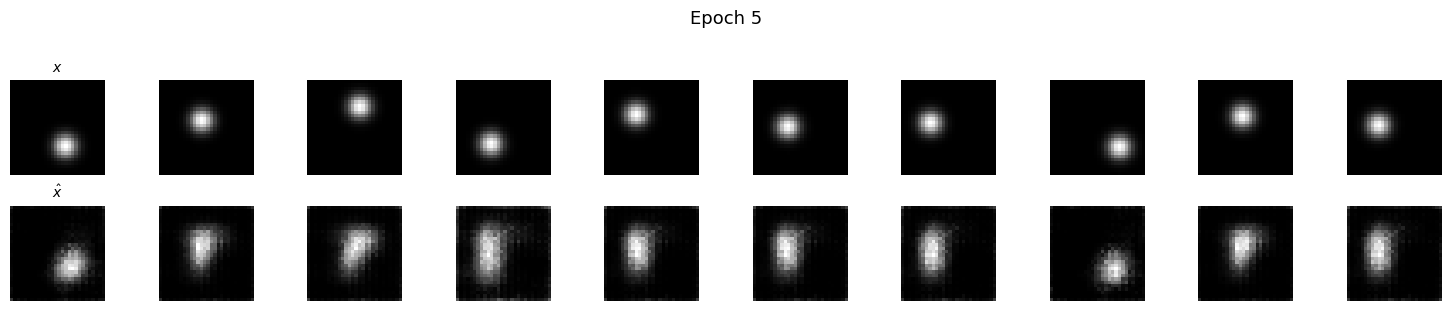

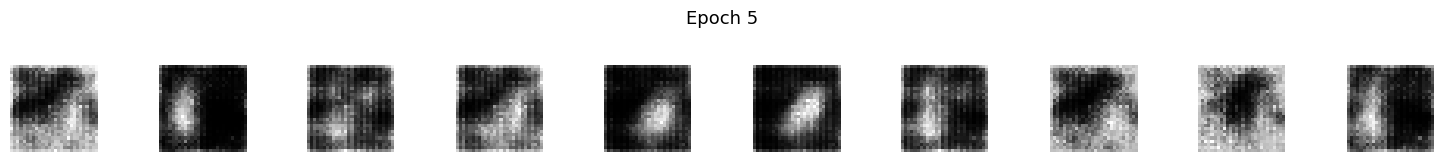

Epoch   6/25 Recon=0.11 D=0.5436 G=3.3744
Epoch   7/25 Recon=0.10 D=0.6146 G=2.3432
Epoch   8/25 Recon=0.09 D=0.6531 G=2.1262
Epoch   9/25 Recon=0.09 D=0.7075 G=1.9591
Epoch  10/25 Recon=0.08 D=0.7807 G=1.7572


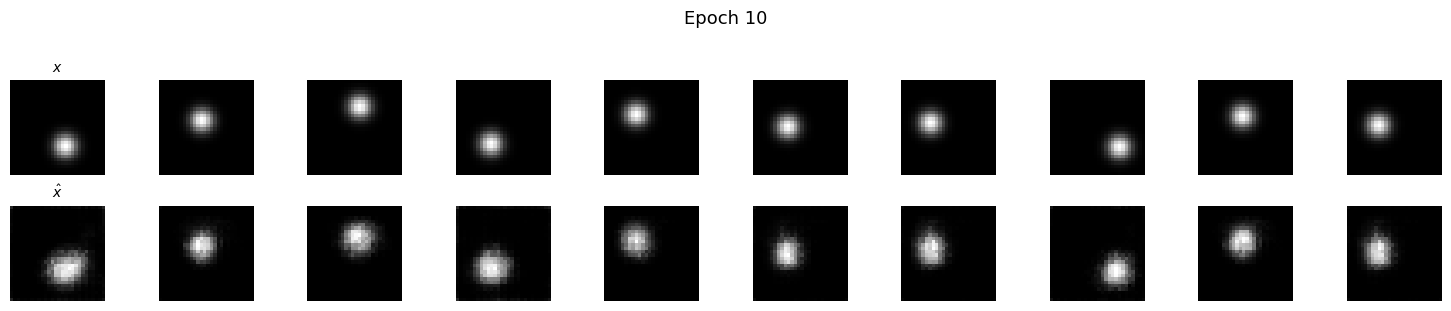

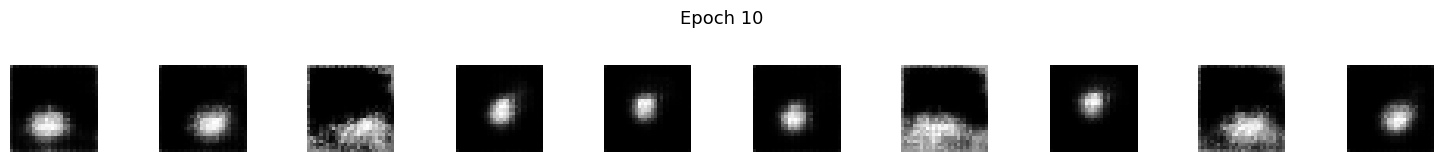

Epoch  11/25 Recon=0.08 D=0.8127 G=1.6177
Epoch  12/25 Recon=0.08 D=0.8542 G=1.5402
Epoch  13/25 Recon=0.08 D=0.8943 G=1.4709
Epoch  14/25 Recon=0.08 D=0.8276 G=1.6515
Epoch  15/25 Recon=0.09 D=0.2333 G=6.6660


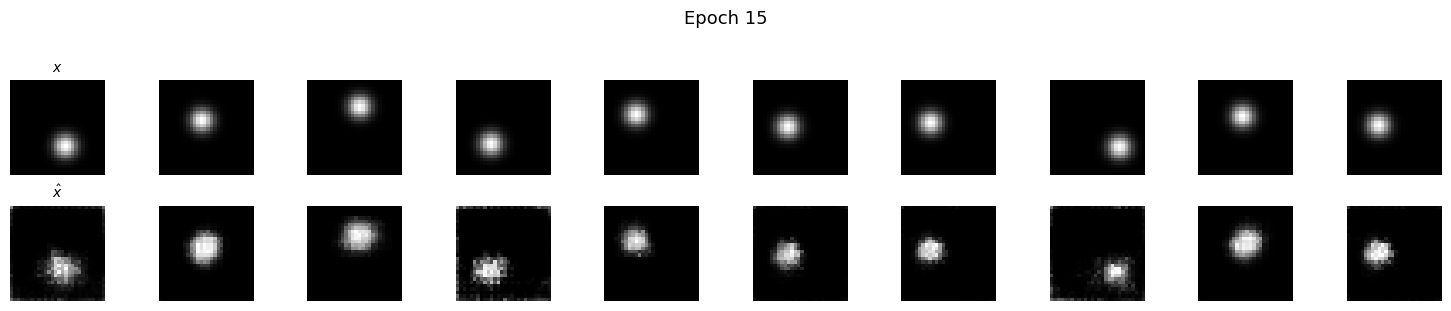

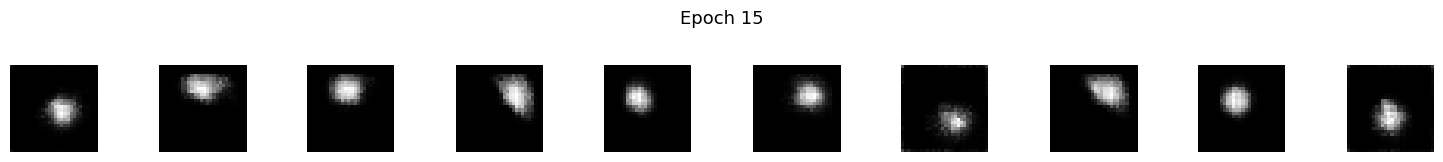

Epoch  16/25 Recon=0.10 D=0.6101 G=8.9766
Epoch  17/25 Recon=0.10 D=0.6923 G=4.9077
Epoch  18/25 Recon=0.09 D=0.3346 G=9.1890
Epoch  19/25 Recon=0.08 D=1.1689 G=1.8640
Epoch  20/25 Recon=0.08 D=0.9299 G=1.8204


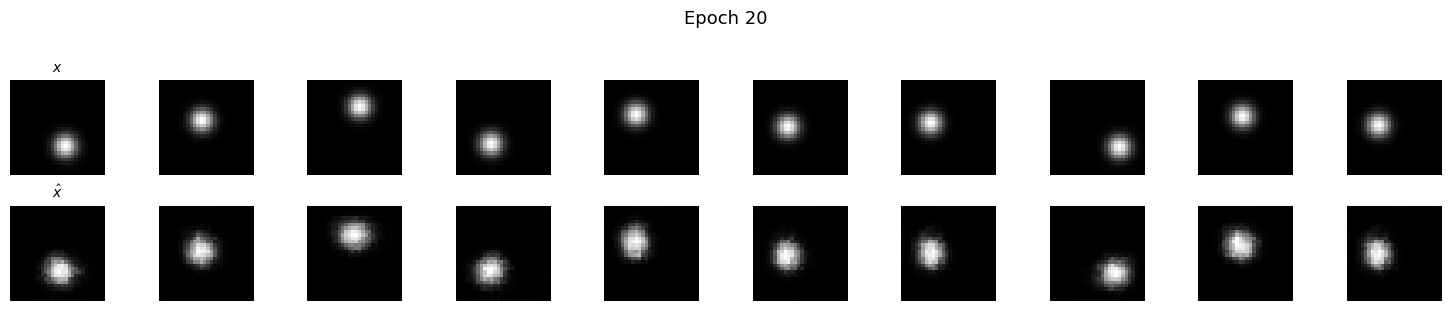

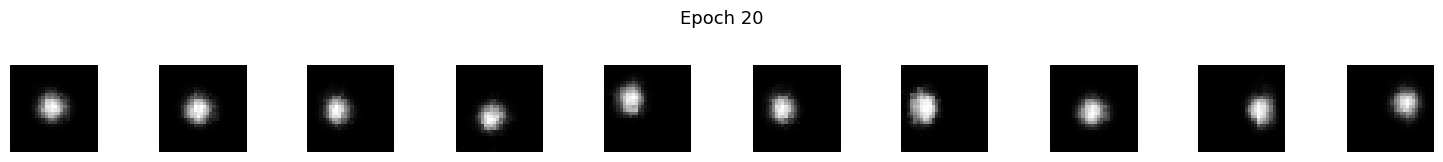

Epoch  21/25 Recon=0.08 D=0.7562 G=3.0524
Epoch  22/25 Recon=0.08 D=1.1089 G=1.5747
Epoch  23/25 Recon=0.08 D=0.6294 G=2.3182
Epoch  24/25 Recon=0.08 D=1.1595 G=1.4360
Epoch  25/25 Recon=0.08 D=1.3317 G=0.8002


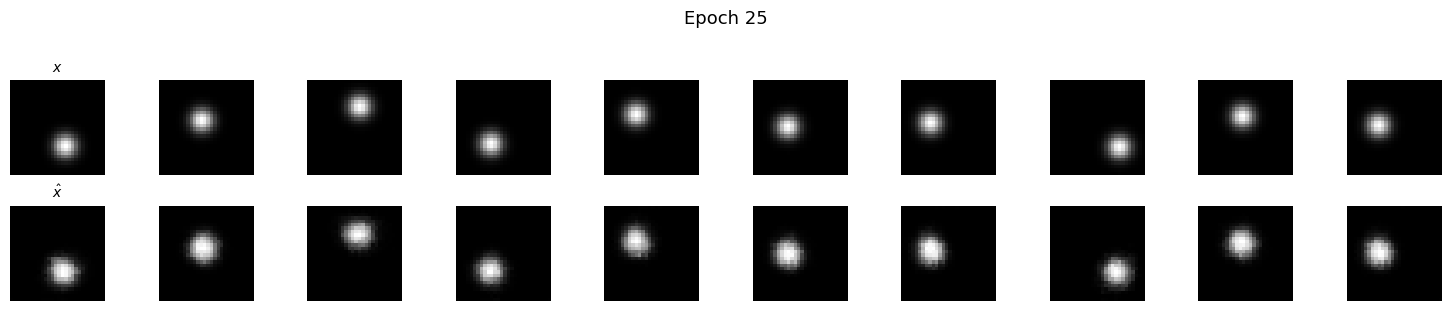

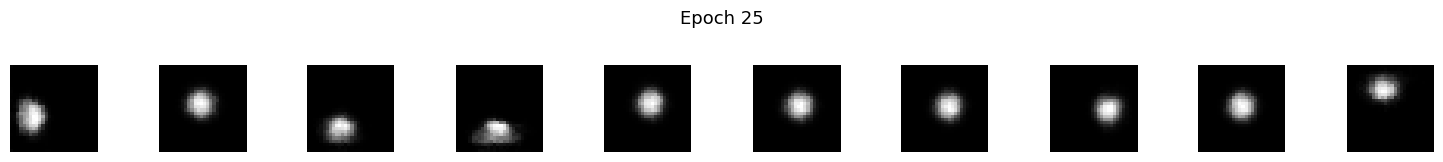

In [12]:
seed_everything(9951)

aae = AdversarialAutoencoder(
    hidden_channels=hidden_channels,
    latent_dim=latent_dim,
).to(device)

history = train_aae(aae, train_loader, epochs=epochs, lr=lr, lr_reg=lr_reg)

### 4. Evaluation

Evaluates the trained model on the hidden test set. **Do not alter this section.**

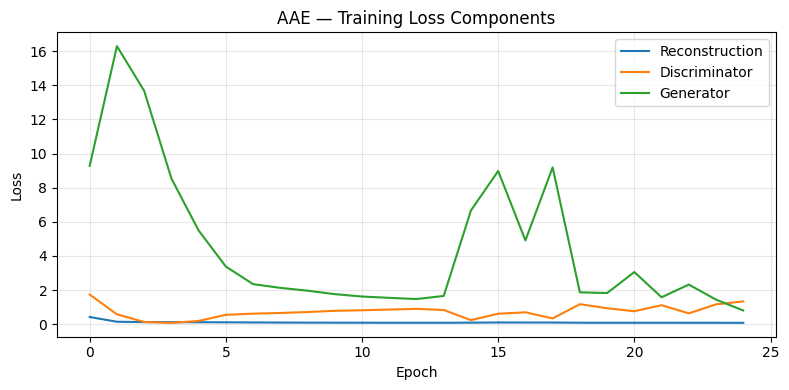

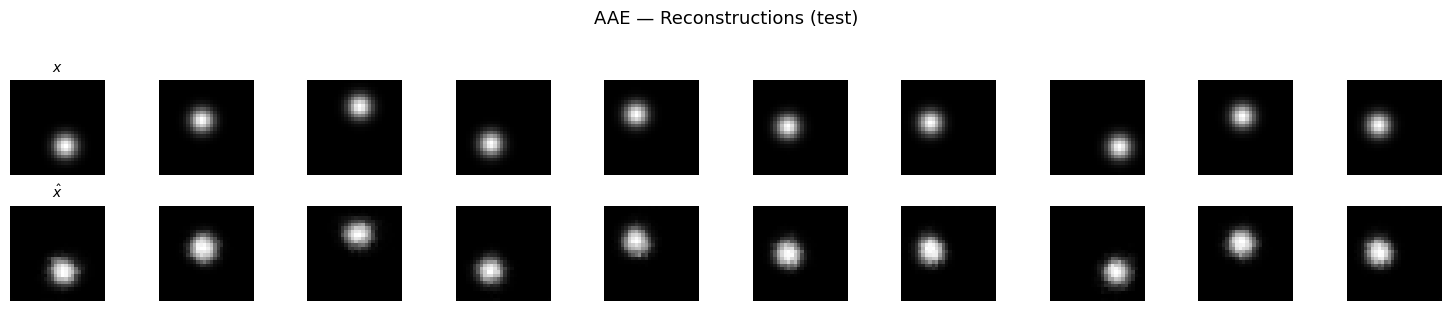

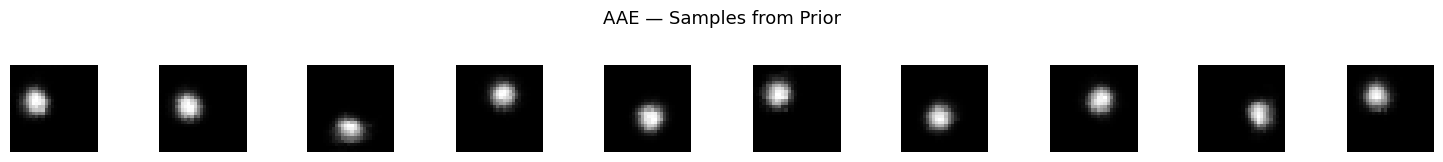

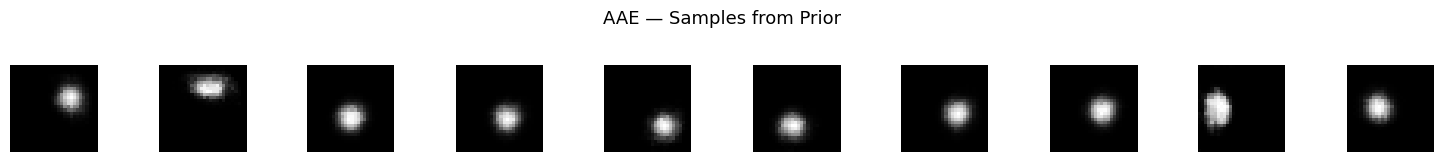

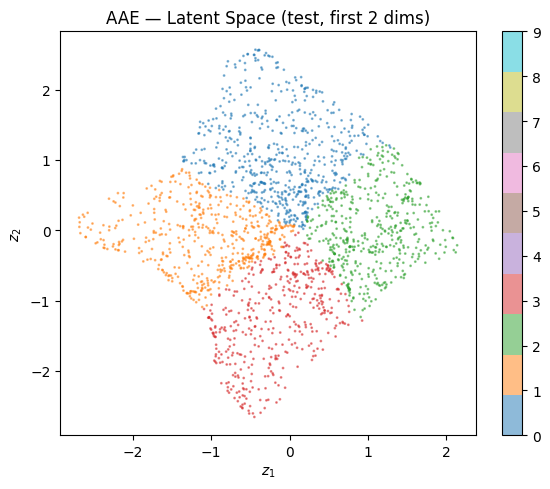

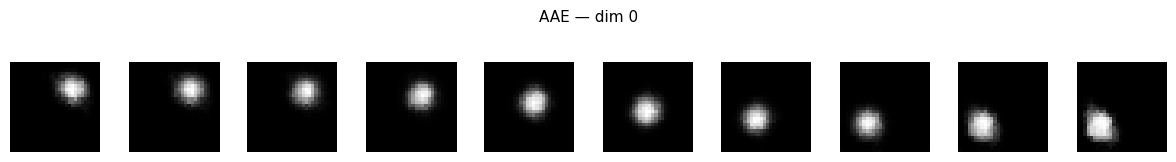

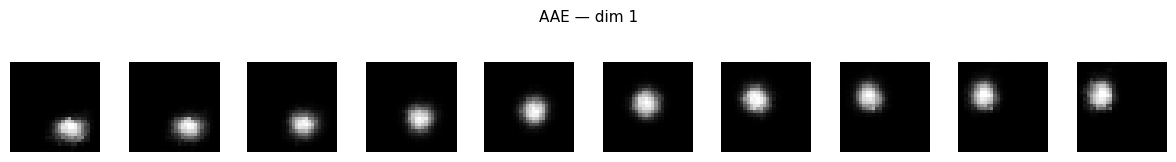

Discriminator accuracy (real vs. fake): 0.5148  (ideal ≈ 0.50)


0.51484375

In [13]:
plot_losses(history, "AAE — Training Loss Components")
show_reconstructions(aae, test_loader, title="AAE — Reconstructions (test)")
show_samples(aae, n=10, title="AAE — Samples from Prior")
show_samples(aae, n=10, title="AAE — Samples from Prior")
show_latent_space(aae, test_loader, title="AAE — Latent Space (test, first 2 dims)")
for dim in range(latent_dim):
    show_latent_traversal(aae, dim_to_traverse=dim, title="AAE")
discriminator_accuracy(aae, test_loader)